# Data Analytics — Exercise 7.5: Linear Regression with Scikit-learn 
## Marenza Santarin | 5/22/2026

This notebook builds a machine learning model to predict median house prices in Boston neighborhoods. The goal is to train, test, evaluate, and visualize a Linear Regression model using scikit-learn.

## 1. Install Libraries & Load Dataset

In [17]:
# Importing pandas to load and work with the CSV file as a DataFrame.
import pandas as pd

# Importing numpy for numerical calculations.
import numpy as np

# Importing matplotlib to create charts.
import matplotlib.pyplot as plt

# Importing train_test_split to separate the data into training and testing sets.
from sklearn.model_selection import train_test_split

# Importing LinearRegression to build the prediction model.
from sklearn.linear_model import LinearRegression

# Importing metrics to evaluate how well the model performed.
from sklearn import metrics

# Loading the housing.csv file into a DataFrame called boston.
boston = pd.read_csv('housing.csv')

# Showing the first 5 rows to preview the data.
print(boston.head())
print()

# Showing the number of rows and columns.
print(boston.shape)
print()

# Showing the data type of each column.
print(boston.dtypes)
print()

# Checking if any column has missing values.
print(boston.isnull().sum())

# Bringing in the libraries needed. Then I’m reading housing.csv and saving it into a DataFrame called boston. After that,
# I’m checking what the data looks like, how big it is, what kind of values each column has, and whether anything is missing.

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

(40, 14)

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0

## 2. Explore and Inspect the Dataset

In [18]:
# Showing summary statistics for all numeric columns.
print(boston.describe().round(2))

# Checking how strongly each column is related to MEDV.
print(boston.corr()['MEDV'].sort_values())

# describe() gives me the overall summary of the dataset, like average, minimum, maximum, and spread. 
# The correlation line is asking which columns move most closely with MEDV. 
# Positive values move up with price. Negative values move opposite of price.

        CRIM     ZN  INDUS  CHAS    NOX     RM     AGE    DIS    RAD     TAX  \
count  40.00  40.00  40.00  40.0  40.00  40.00   40.00  40.00  40.00   40.00   
mean    0.59   2.64   7.23   0.0   0.52   6.08   73.72   4.62   4.03  295.00   
std     0.48   5.41   1.82   0.0   0.03   0.40   20.49   0.93   0.89   26.67   
min     0.01   0.00   2.18   0.0   0.46   5.46   29.30   3.36   1.00  222.00   
25%     0.10   0.00   7.67   0.0   0.52   5.85   61.32   3.91   4.00  304.25   
50%     0.65   0.00   8.14   0.0   0.54   5.98   81.25   4.45   4.00  307.00   
75%     0.96   0.00   8.14   0.0   0.54   6.17   90.65   5.09   5.00  307.00   
max     1.61  18.00   8.14   0.0   0.54   7.18  100.00   6.59   5.00  311.00   

       PTRATIO       B  LSTAT   MEDV  
count    40.00   40.00  40.00  40.00  
mean     19.33  372.51  13.63  20.00  
std       2.30   40.83   6.09   6.75  
min      15.20  232.60   2.94   7.00  
25%      18.48  376.80   9.54  16.18  
50%      21.00  389.22  13.28  20.35  
75%   

The feature that appears most positively related to MEDV is RM, which means neighborhoods with more average rooms tend to have higher median home values. The most negatively related feature is TAX, which means higher property tax rates appear connected with lower median home values in this dataset. These correlations give us an early clue about which columns may be important, but the model will still use all features together.

## 3. Split the Dataset

In [19]:
# Creating X by removing MEDV because MEDV is the answer we want to predict.
X = boston.drop('MEDV', axis=1)

# Creating y by selecting only MEDV as the target column.
y = boston['MEDV']

# Splitting the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # 0.2 means 20% of the data is saved for testing, 80% for training.
)

# Printing the shapes so we can confirm the split worked correctly.
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

# Separating the columns into two parts. X has the columns the model will learn from. y has the answer column. 
# Then train_test_split() gives most of the rows to training and saves a smaller part for testing. Since the dataset 
# has 40 rows, 80% training gives 32 rows, and 20% testing gives 8 rows.

X_train shape: (32, 13)
X_test shape: (8, 13)
y_train shape: (32,)
y_test shape: (8,)


## 4. Instantiate the Estimator & Train with fit() (Training the Linear Regression Model)

In [20]:
# Creating an empty Linear Regression model.
model = LinearRegression()

# Training the model using the training features and training answers.
model.fit(X_train, y_train)

# Printing the intercept, which is the model's starting point.
print(f'Intercept: {model.intercept_:.4f}')

# Creating a DataFrame to match each feature with its coefficient.
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# Sorting the coefficients from highest to lowest.
print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))

# model = LinearRegression() creates the model, but it has not learned anything yet. fit() is where the learning happens. 
# I’m telling the model to study X_train and compare it to y_train so you can learn the pattern between the features and house prices.
# The intercept is the starting prediction, and the coefficients show how each feature affects the prediction.

Intercept: -94.5051
Feature   Coefficient
     RM  8.250974e+00
PTRATIO  7.283802e+00
  INDUS  3.371763e+00
     ZN  3.150322e+00
    DIS  2.593520e+00
   CRIM  2.948754e-01
  LSTAT  2.424564e-01
    RAD  2.176374e-01
    NOX  7.429795e-02
      B  2.616249e-02
   CHAS  1.647293e-14
    AGE -1.548640e-01
    TAX -4.190639e-01


The fit() method trained the model. It studied the training data and learned the relationship between the feature columns and the MEDV target column. After fitting, the model now has an intercept and coefficients that it can use to make predictions.

## 5. Generate Predictions with predict() & Evaluate with score()

In [21]:
# Using the trained model to predict MEDV values for the test features.
y_pred = model.predict(X_test)

# Using score() to get the R-squared value from the model.
r2_from_score = model.score(X_test, y_test)

# Calculating Mean Absolute Error.
mae = metrics.mean_absolute_error(y_test, y_pred)

# Calculating Mean Squared Error.
mse = metrics.mean_squared_error(y_test, y_pred)

# Calculating R-squared using metrics.
r2 = metrics.r2_score(y_test, y_pred)

# Printing all evaluation results with 4 decimal places.
print(f'MAE: {mae:.4f}')
print(f'MSE: {mse:.4f}')
print(f'R² from metrics: {r2:.4f}')
print(f'R² from score(): {r2_from_score:.4f}')

MAE: 5.3359
MSE: 52.0024
R² from metrics: 0.4153
R² from score(): 0.4153


The score() method and r2_score() both return the R-squared value for this regression model. The difference is that score() comes directly from the trained model, while r2_score() comes from sklearn.metrics and compares y_test to y_pred manually. In this exercise, they should match because both are measuring the same thing.

## 6. Visualize Actual vs Predicted Prices

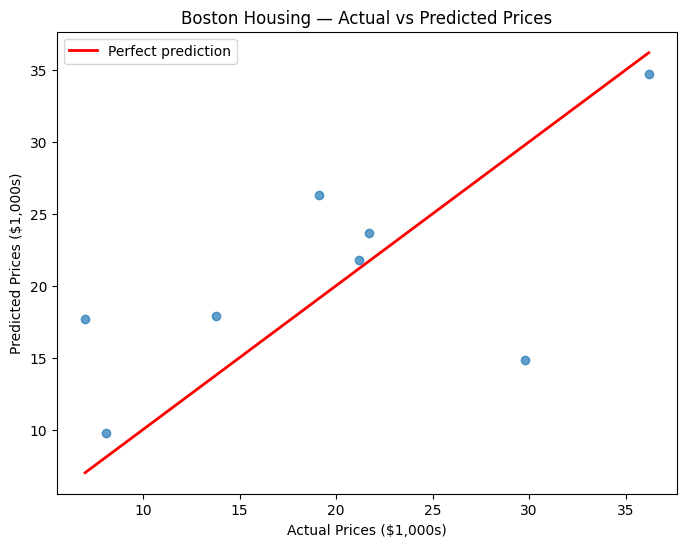

In [22]:
# Creating the figure size for the chart.
plt.figure(figsize=(8, 6))

# Creating a scatter plot comparing actual prices to predicted prices.
plt.scatter(y_test, y_pred, alpha=0.7)

# Adding a diagonal line that represents perfect predictions.
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    label='Perfect prediction'
)

# Labeling the x-axis.
plt.xlabel('Actual Prices ($1,000s)')

# Labeling the y-axis.
plt.ylabel('Predicted Prices ($1,000s)')

# Adding the chart title.
plt.title('Boston Housing — Actual vs Predicted Prices')

# Showing the legend.
plt.legend()

# Displaying the chart.
plt.show()

# The scatter plot compares real prices to predicted prices. Each dot is one test row. The red line shows where the dots 
# would land if the model predicted perfectly. The closer the dots are to the red line, the better the model did.

Summary:

The Linear Regression model was able to learn some patterns in the housing data, but the R² score shows that the model only explained part of the variation in MEDV. The MAE shows the model’s predictions were off by about 5.34, which means about $5,340 because MEDV is measured in 1,000s. Overall, the model gives a useful first prediction, but it could likely improve with more data or a different model.